In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IRIS.csv to IRIS.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [ ]:
df = pd.read_csv('IRIS.csv')

DATA INFORMATION

In [ ]:
df.head(5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.tail(5)

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
df.shape

(150, 5)

In [ ]:
df.duplicated().sum()

np.int64(3)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(147, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB


In [ ]:
df.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


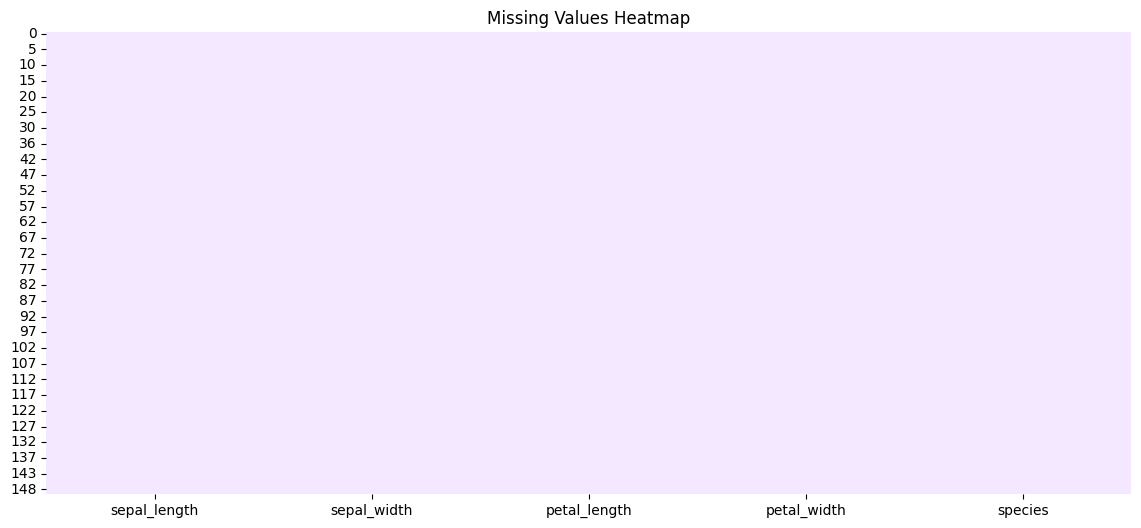

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

graph = LinearSegmentedColormap.from_list(
    "medium_lilac",
    ["#F3E8FF", "#E9D5FF", "#D8B4FE", "#A855F7"]
)

plt.figure(figsize=(14,6))

sns.heatmap(  df.isnull(),cbar=False,cmap=graph
)

plt.title("Missing Values Heatmap")
plt.show()

DATA PREPROCESSING

In [ ]:
encoder = LabelEncoder()

df["species"] = encoder.fit_transform(df["species"])

print("\nEncoded Classes:")
print(dict(zip(encoder.classes_,
               encoder.transform(encoder.classes_))))


Encoded Classes:
{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


EDA

/tmp/ipykernel_579/2525472821.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


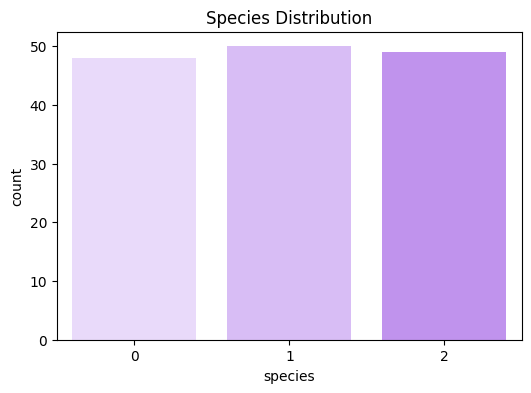

In [ ]:
# Class Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x="species",
    data=df,
    palette=["#E9D5FF", "#D8B4FE", "#C084FC"]
)

plt.title("Species Distribution")
plt.show()



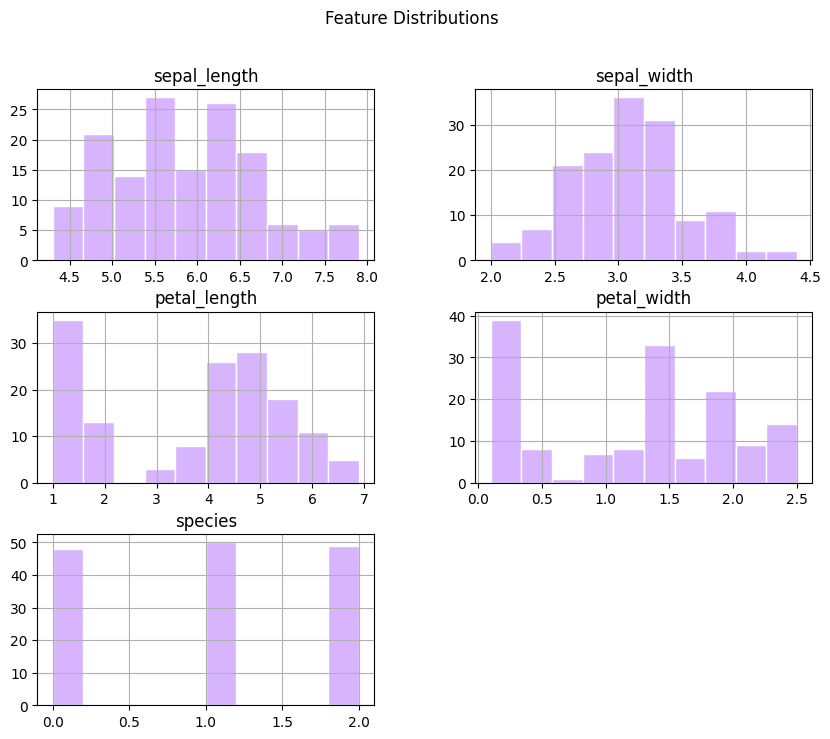

In [ ]:
# Histograms
df.hist(
    figsize=(10,8),
    color="#D8B4FE",
    edgecolor="white"
)

plt.suptitle("Feature Distributions")
plt.show()



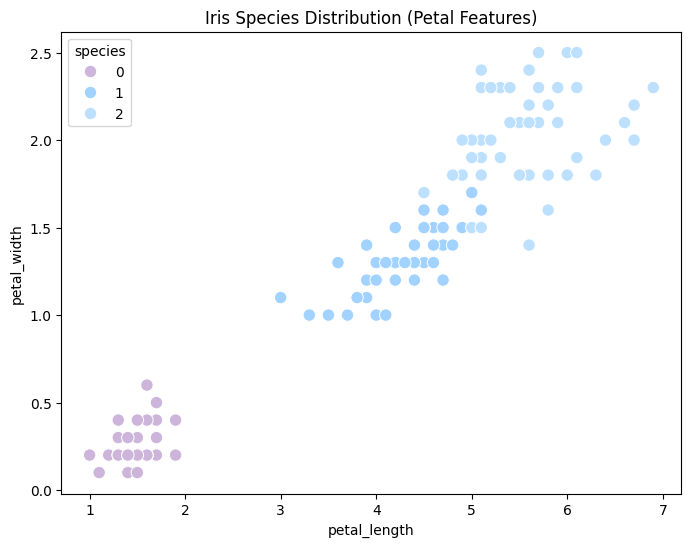

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    palette=["#CDB4DB", "#A2D2FF", "#BDE0FE"],
    s=80
)

plt.title("Iris Species Distribution (Petal Features)")
plt.show()

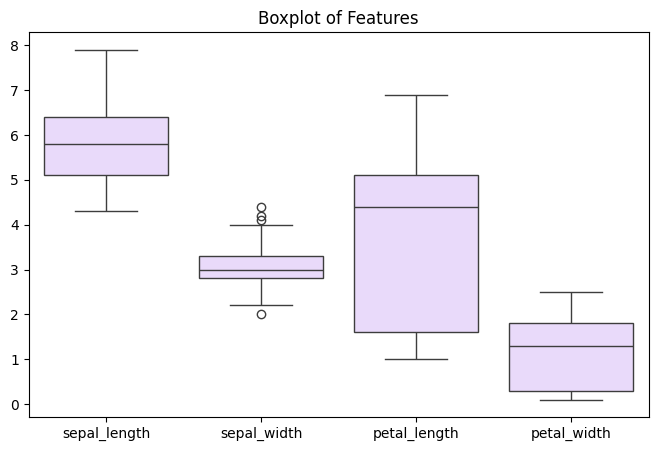

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df.iloc[:, :-1],
    color="#E9D5FF"
)

plt.title("Boxplot of Features")
plt.show()



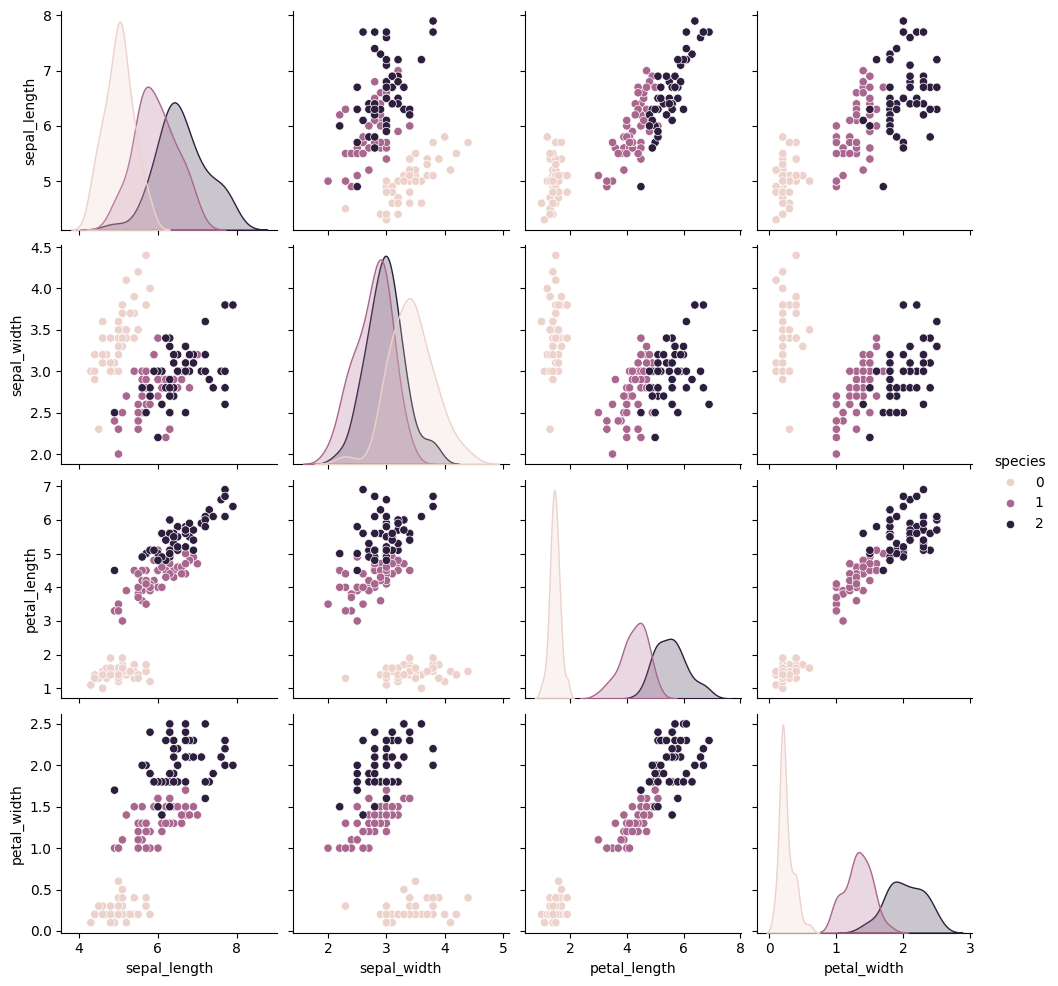

In [ ]:
# Pairplot

sns.pairplot(
    df,
    hue="species"
)
plt.show()



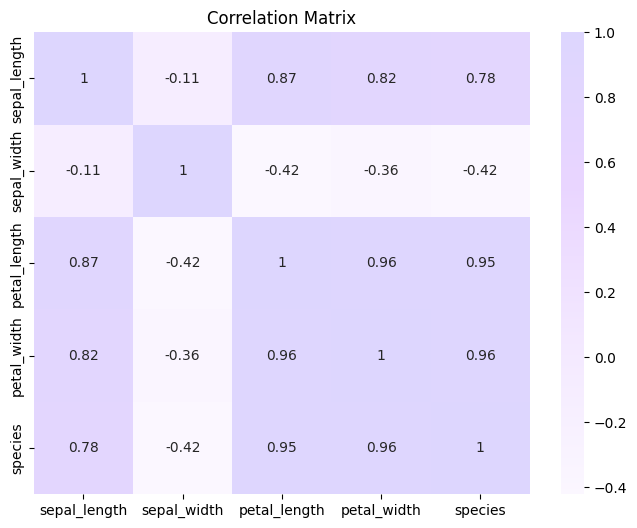

In [ ]:
cmap = LinearSegmentedColormap.from_list(
    "soft_lilac",
    ["#FBF7FF", "#F3E8FF", "#E9D5FF", "#DDD6FE"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap=cmap
)

plt.title("Correlation Matrix")
plt.show()

FEATURE SELECTION

In [ ]:
X = df.drop("species", axis=1)

y = df["species"]

TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

In [ ]:
print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 117
Testing Samples : 30


FEATURE SCALING

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ML MODELS BUILDING

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN Results:")
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred, average='macro'))
print("Recall   :", recall_score(y_test, knn_pred, average='macro'))
print("F1 Score :", f1_score(y_test, knn_pred, average='macro'))

KNN Results:
Accuracy : 0.9333333333333333
Precision: 0.9444444444444445
Recall   : 0.9333333333333332
F1 Score : 0.9326599326599326


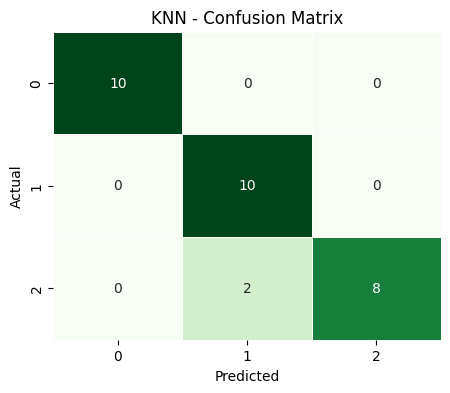

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

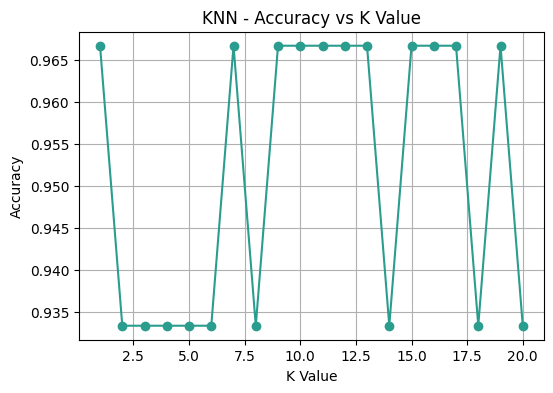

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_range = range(1, 21)
scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(6,4))

plt.plot(k_range, scores, marker='o', color="#2a9d8f")

plt.title("KNN - Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

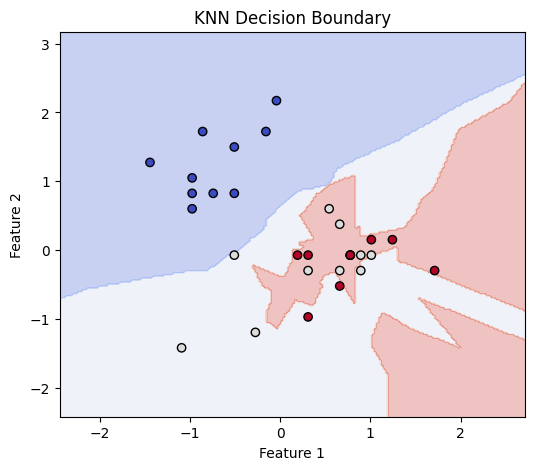

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

X_vis = X_test_scaled[:, :2]
y_vis = y_test

knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis, y_vis)

x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, cmap="coolwarm", edgecolor="k")

plt.title("KNN Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

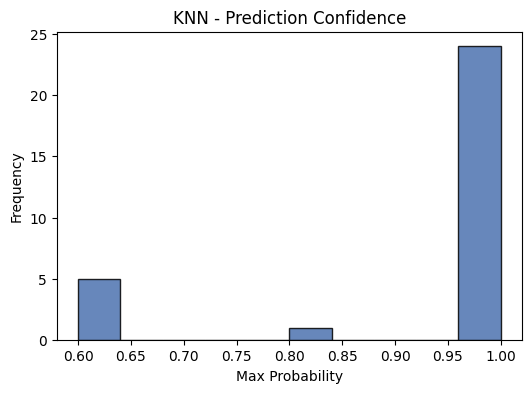

In [ ]:
import numpy as np

probs = knn_model.predict_proba(X_test_scaled)

plt.figure(figsize=(6,4))

plt.hist(
    np.max(probs, axis=1),
    bins=10,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.85
)

plt.title("KNN - Prediction Confidence")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")
plt.show()

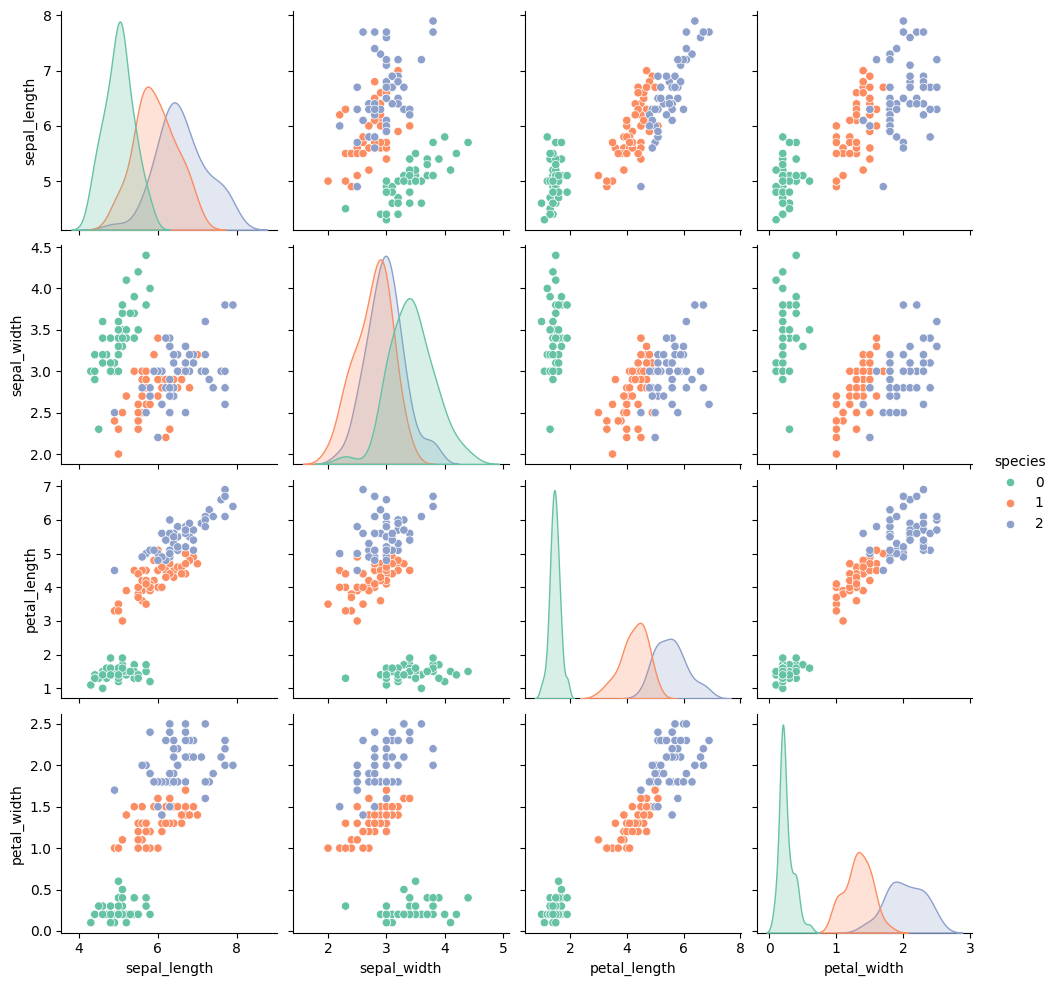

In [ ]:
import seaborn as sns

df_plot = df.copy()
df_plot["species"] = y

sns.pairplot(df_plot, hue="species", palette="Set2")

plt.show()

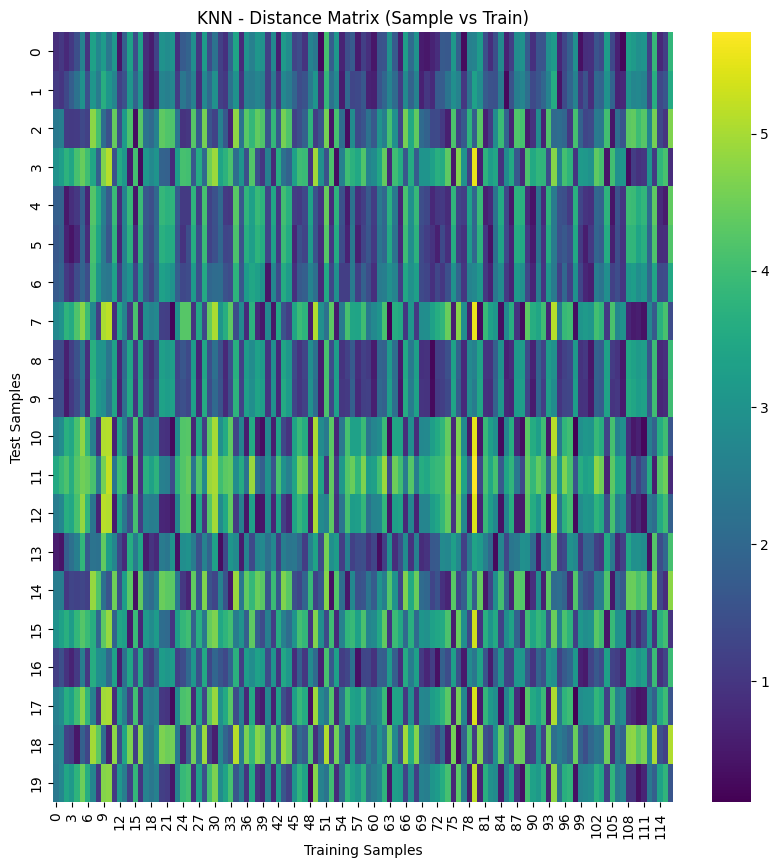

In [ ]:
import numpy as np
import seaborn as sns

sample = X_test_scaled[:20]
distances = np.linalg.norm(sample[:, None] - X_train_scaled[None, :], axis=2)

plt.figure(figsize=(10,10))

sns.heatmap(
    distances,
    cmap="viridis"
)

plt.title("KNN - Distance Matrix (Sample vs Train)")
plt.xlabel("Training Samples")
plt.ylabel("Test Samples")
plt.show()

LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred, average='macro'))
print("Recall   :", recall_score(y_test, log_pred, average='macro'))
print("F1 Score :", f1_score(y_test, log_pred, average='macro'))

Logistic Regression Results:
Accuracy : 0.9333333333333333
Precision: 0.9333333333333332
Recall   : 0.9333333333333332
F1 Score : 0.9333333333333332


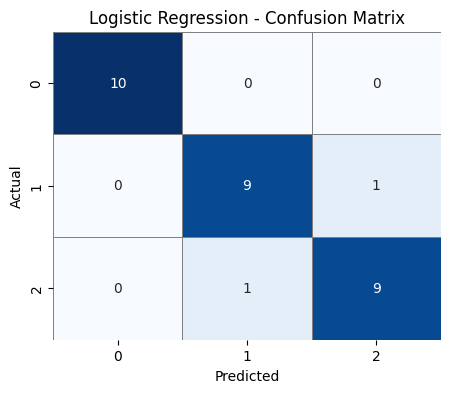

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

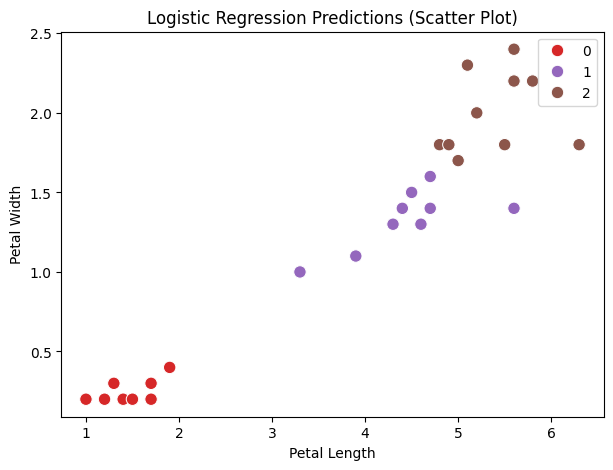

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_test["petal_length"],
    y=X_test["petal_width"],
    hue=log_pred,
    palette=["#d62728", "#9467bd", "#8c564b"],
    s=80
)

plt.title("Logistic Regression Predictions (Scatter Plot)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

/tmp/ipykernel_579/1620988045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


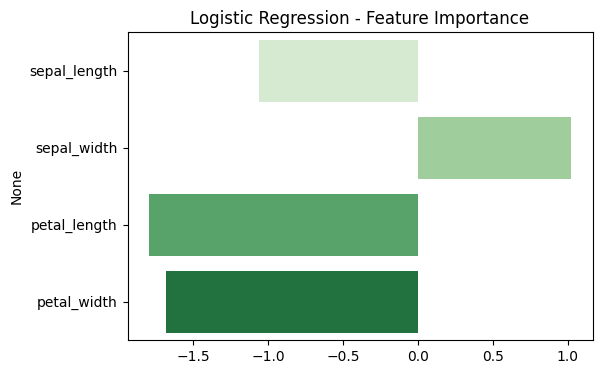

In [ ]:
import numpy as np

features = X.columns
coeff = log_model.coef_[0]

plt.figure(figsize=(6,4))

sns.barplot(
    x=coeff,
    y=features,
    palette="Greens"
)

plt.title("Logistic Regression - Feature Importance")
plt.show()

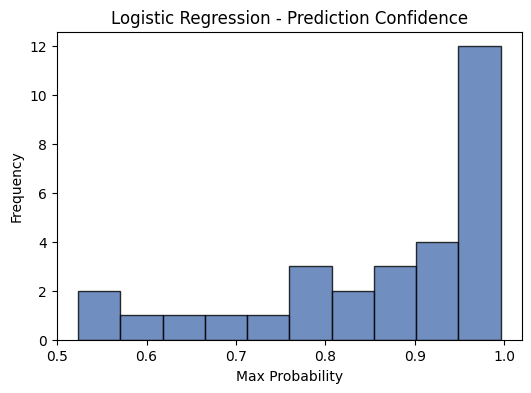

In [ ]:
import numpy as np

probs = log_model.predict_proba(X_test_scaled)

plt.figure(figsize=(6,4))

plt.hist(
    np.max(probs, axis=1),
    bins=10,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.8
)

plt.title("Logistic Regression - Prediction Confidence")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")
plt.show()

RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest Results:")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average='macro'))
print("Recall   :", recall_score(y_test, rf_pred, average='macro'))
print("F1 Score :", f1_score(y_test, rf_pred, average='macro'))

Random Forest Results:
Accuracy : 0.9666666666666667
Precision: 0.9696969696969697
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778612


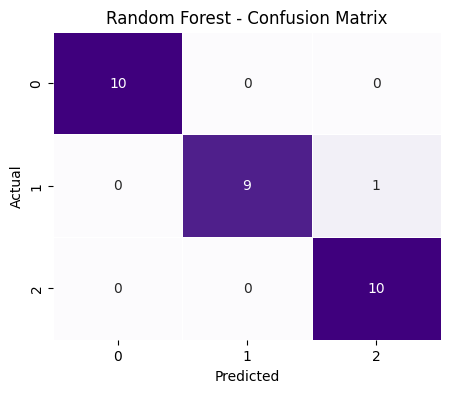

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_579/4191208557.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


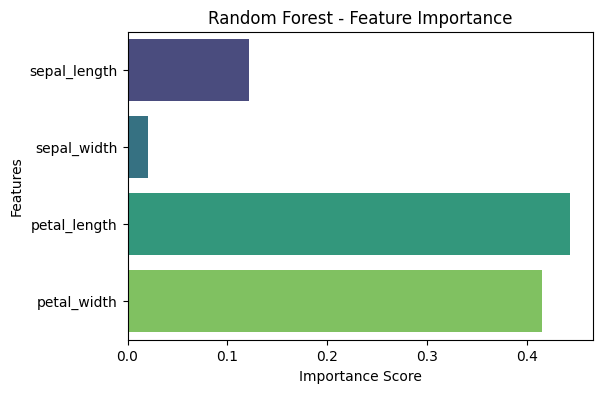

In [ ]:
import numpy as np

importance = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))

sns.barplot(
    x=importance,
    y=features,
    palette="viridis"
)

plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

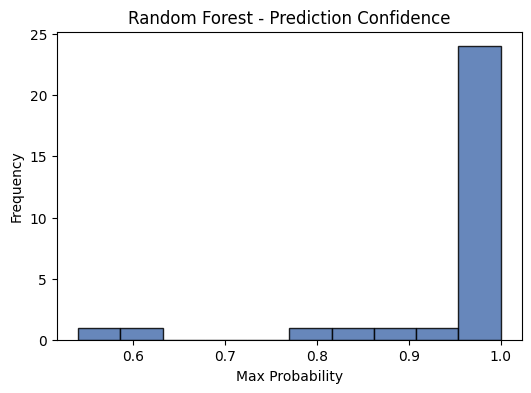

In [ ]:
import numpy as np

probs = rf_model.predict_proba(X_test_scaled)

plt.figure(figsize=(6,4))

plt.hist(
    np.max(probs, axis=1),
    bins=10,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.85
)

plt.title("Random Forest - Prediction Confidence")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")
plt.show()

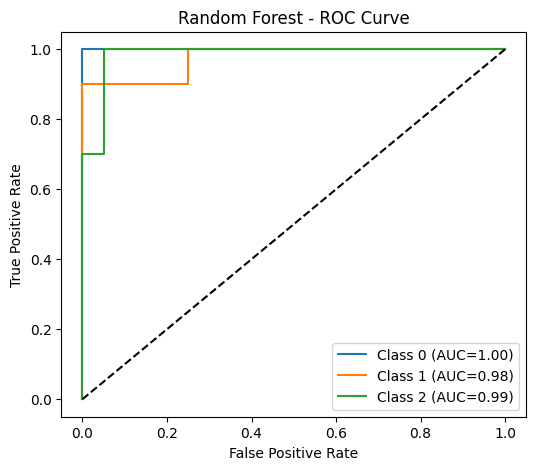

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = rf_model.predict_proba(X_test_scaled)

plt.figure(figsize=(6,5))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[i],
             label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],"k--")

plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

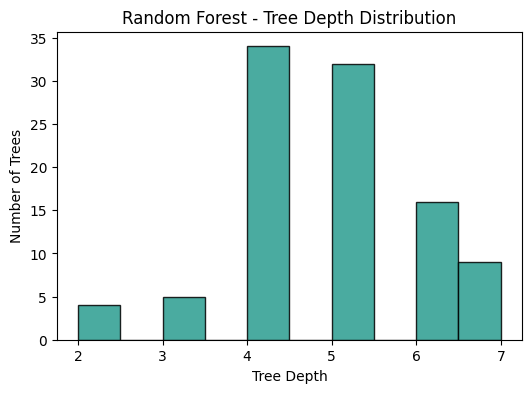

In [ ]:
tree_depths = [tree.get_depth() for tree in rf_model.estimators_]

plt.figure(figsize=(6,4))

plt.hist(
    tree_depths,
    bins=10,
    color="#2a9d8f",
    edgecolor="black",
    alpha=0.85
)

plt.title("Random Forest - Tree Depth Distribution")
plt.xlabel("Tree Depth")
plt.ylabel("Number of Trees")
plt.show()

DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree Results:")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, average='macro'))
print("Recall   :", recall_score(y_test, dt_pred, average='macro'))
print("F1 Score :", f1_score(y_test, dt_pred, average='macro'))

Decision Tree Results:
Accuracy : 0.9333333333333333
Precision: 0.9333333333333332
Recall   : 0.9333333333333332
F1 Score : 0.9333333333333332


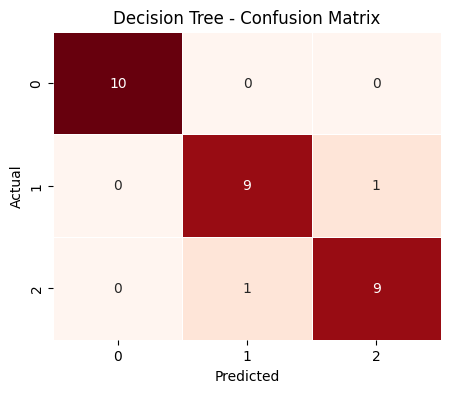

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

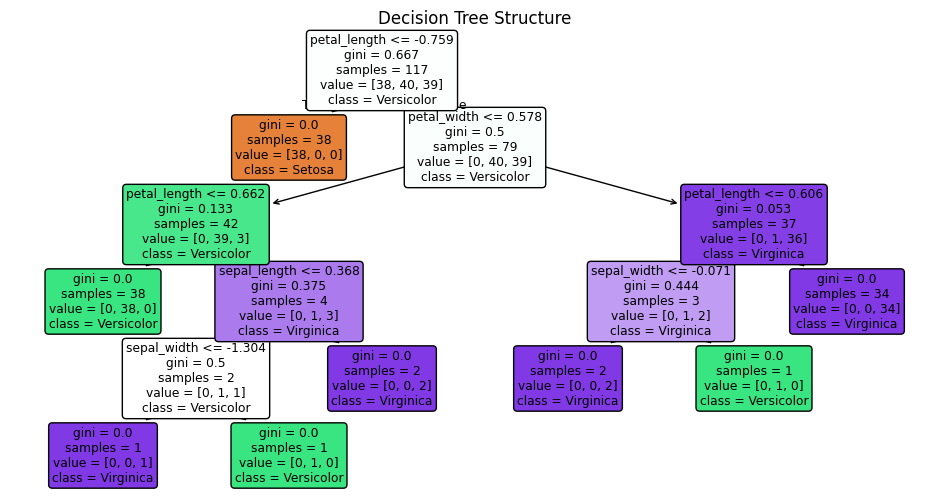

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

tree.plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Setosa", "Versicolor", "Virginica"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Structure")
plt.show()

/tmp/ipykernel_579/194906116.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


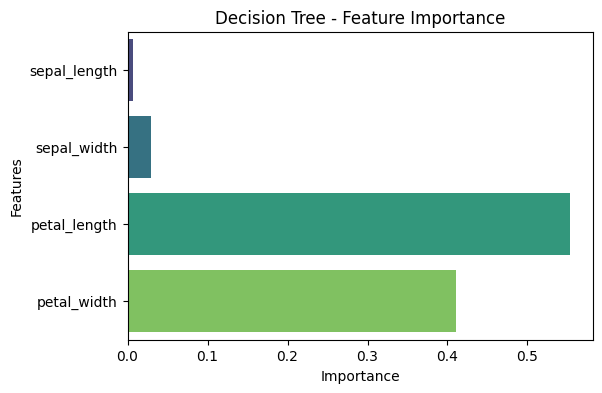

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

importance = dt_model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))

sns.barplot(
    x=importance,
    y=features,
    palette="viridis"
)

plt.title("Decision Tree - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

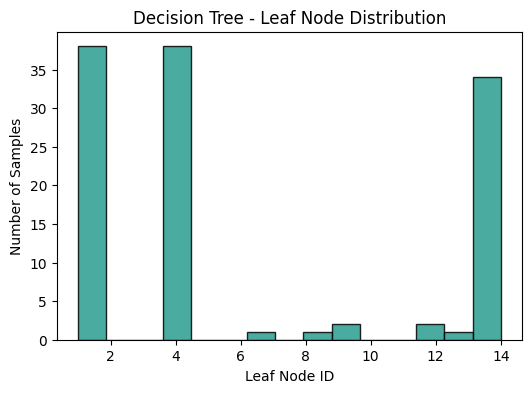

In [ ]:
leaf_nodes = dt_model.apply(X_train_scaled)

plt.figure(figsize=(6,4))

plt.hist(
    leaf_nodes,
    bins=15,
    color="#2a9d8f",
    edgecolor="black",
    alpha=0.85
)

plt.title("Decision Tree - Leaf Node Distribution")
plt.xlabel("Leaf Node ID")
plt.ylabel("Number of Samples")
plt.show()

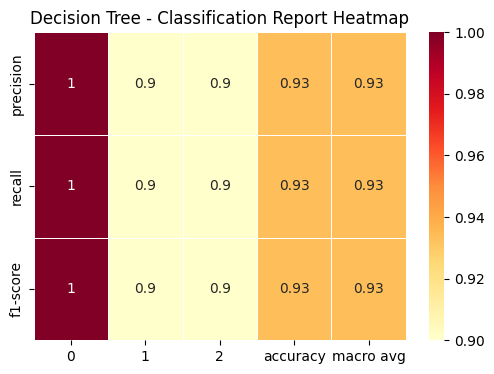

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(y_test, dt_pred, output_dict=True)

df_report = pd.DataFrame(report).iloc[:-1, :-1]

plt.figure(figsize=(6,4))

sns.heatmap(
    df_report,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Decision Tree - Classification Report Heatmap")
plt.show()

NAIVE BAYES

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)

print("Naive Bayes Results:")
print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred, average='macro'))
print("Recall   :", recall_score(y_test, nb_pred, average='macro'))
print("F1 Score :", f1_score(y_test, nb_pred, average='macro'))

Naive Bayes Results:
Accuracy : 0.9333333333333333
Precision: 0.9333333333333332
Recall   : 0.9333333333333332
F1 Score : 0.9333333333333332


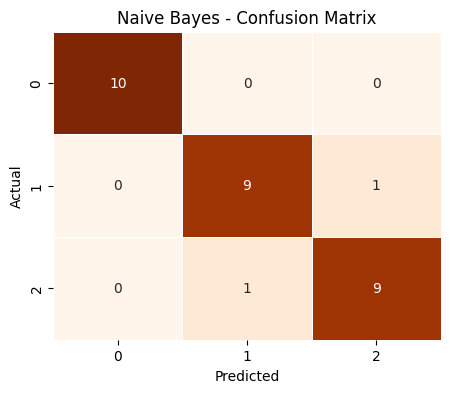

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

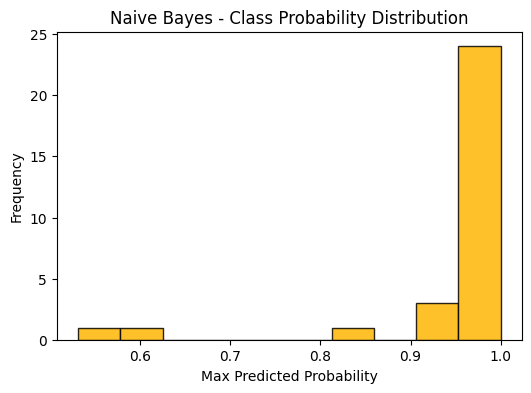

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

probs = nb_model.predict_proba(X_test_scaled)

plt.figure(figsize=(6,4))

plt.hist(
    np.max(probs, axis=1),
    bins=10,
    color="#ffb703",
    edgecolor="black",
    alpha=0.85
)

plt.title("Naive Bayes - Class Probability Distribution")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.show()

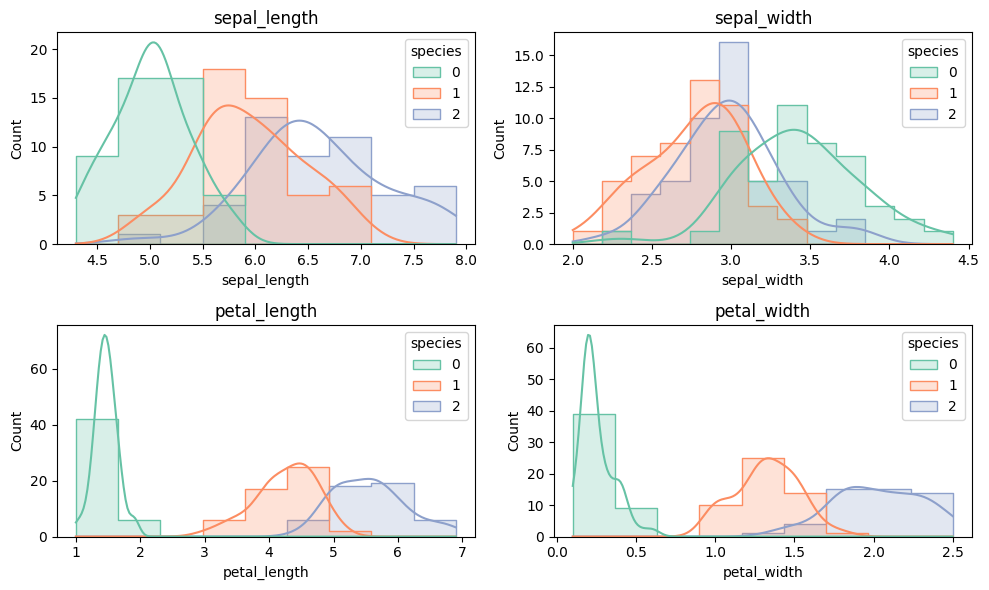

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_temp = X.copy()
df_temp["species"] = y

features = X.columns

plt.figure(figsize=(10,6))

for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.histplot(
        data=df_temp,
        x=col,
        hue="species",
        kde=True,
        palette="Set2",
        element="step"
    )
    plt.title(col)

plt.tight_layout()
plt.show()

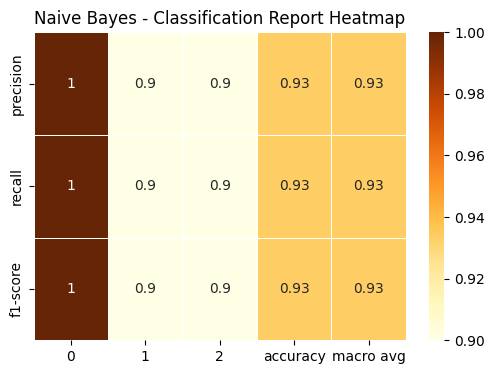

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(y_test, nb_pred, output_dict=True)

df_report = pd.DataFrame(report).iloc[:-1, :-1]

plt.figure(figsize=(6,4))

sns.heatmap(
    df_report,
    annot=True,
    cmap="YlOrBr",
    linewidths=0.5
)

plt.title("Naive Bayes - Classification Report Heatmap")
plt.show()

SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Results:")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred, average='macro'))
print("Recall   :", recall_score(y_test, svm_pred, average='macro'))
print("F1 Score :", f1_score(y_test, svm_pred, average='macro'))

SVM Results:
Accuracy : 0.9666666666666667
Precision: 0.9696969696969697
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778612


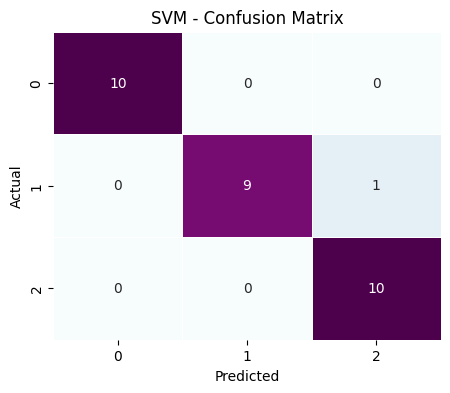

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="BuPu",
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

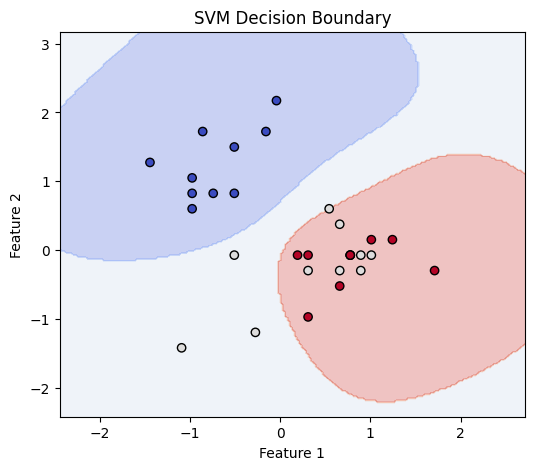

In [ ]:
import numpy as np

X_vis = X_test_scaled[:, :2]  # first 2 features for visualization
y_vis = y_test

svm_vis = SVC(kernel='rbf')
svm_vis.fit(X_vis, y_vis)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap="coolwarm", edgecolor="k")

plt.title("SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

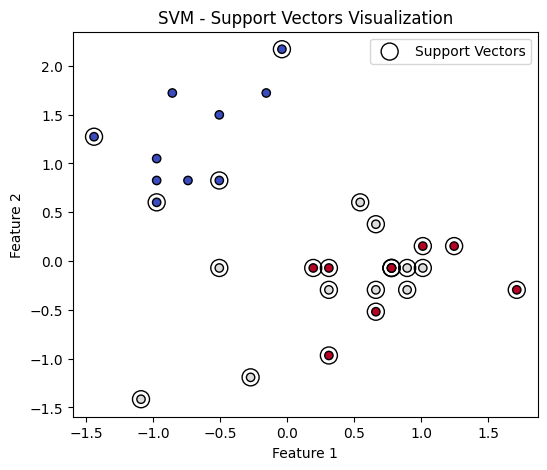

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap="coolwarm", edgecolor="k")

# highlight support vectors
plt.scatter(
    svm_vis.support_vectors_[:, 0],
    svm_vis.support_vectors_[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    label="Support Vectors"
)

plt.title("SVM - Support Vectors Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

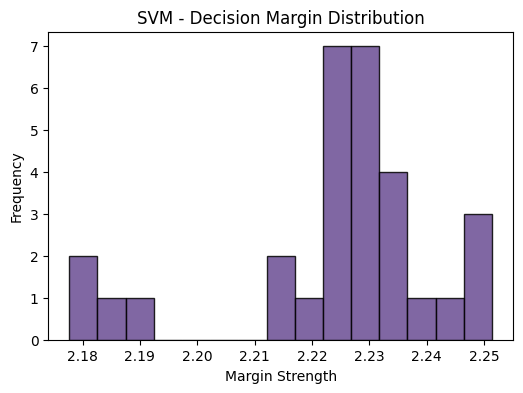

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

decision_values = svm_model.decision_function(X_test_scaled)

# Convert multi-class output → single score per sample
margin_score = np.max(np.abs(decision_values), axis=1)

plt.figure(figsize=(6,4))

plt.hist(
    margin_score,
    bins=15,
    color="#6a4c93",
    edgecolor="black",
    alpha=0.85
)

plt.title("SVM - Decision Margin Distribution")
plt.xlabel("Margin Strength")
plt.ylabel("Frequency")
plt.show()

ML MODELS RESULTS

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
    "Logistic Regression": log_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "Naive Bayes": nb_pred
}

summary = []

for model_name, preds in results.items():
    summary.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='macro'),
        "Recall": recall_score(y_test, preds, average='macro'),
        "F1-Score": f1_score(y_test, preds, average='macro')
    })

df_results = pd.DataFrame(summary)

df_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,KNN,0.933333,0.944444,0.933333,0.932660
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
3,Random Forest,0.966667,0.969697,0.966667,0.966583
4,SVM,0.966667,0.969697,0.966667,0.966583
5,Naive Bayes,0.933333,0.933333,0.933333,0.933333


/tmp/ipykernel_579/4090617826.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


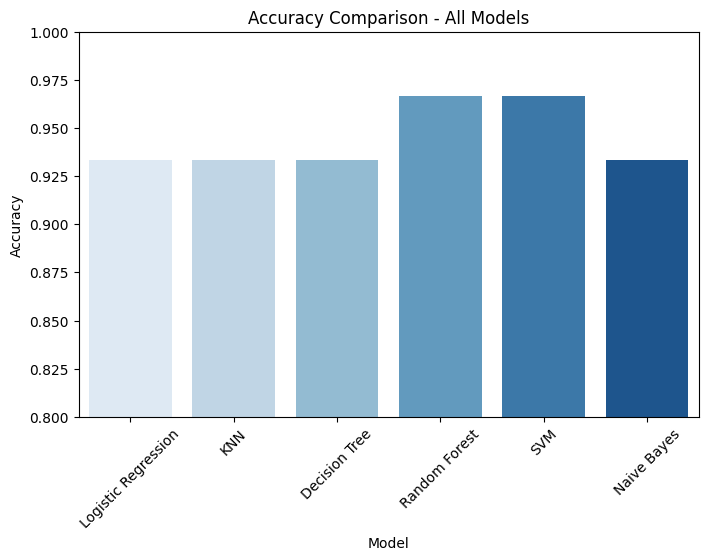

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_results,
    x="Model",
    y="Accuracy",
    palette="Blues"
)

plt.title("Accuracy Comparison - All Models")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.show()

/tmp/ipykernel_579/2574012456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


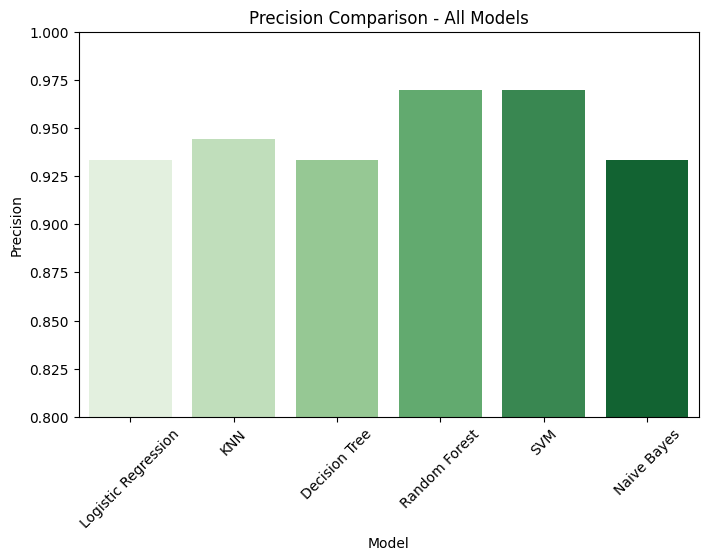

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_results,
    x="Model",
    y="Precision",
    palette="Greens"
)

plt.title("Precision Comparison - All Models")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.show()

/tmp/ipykernel_579/1056087982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


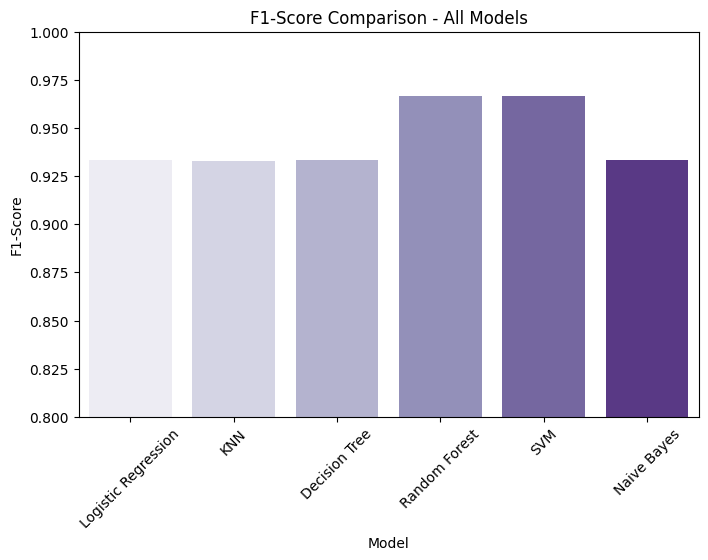

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_results,
    x="Model",
    y="F1-Score",
    palette="Purples"
)

plt.title("F1-Score Comparison - All Models")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.show()

/tmp/ipykernel_579/1503286349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


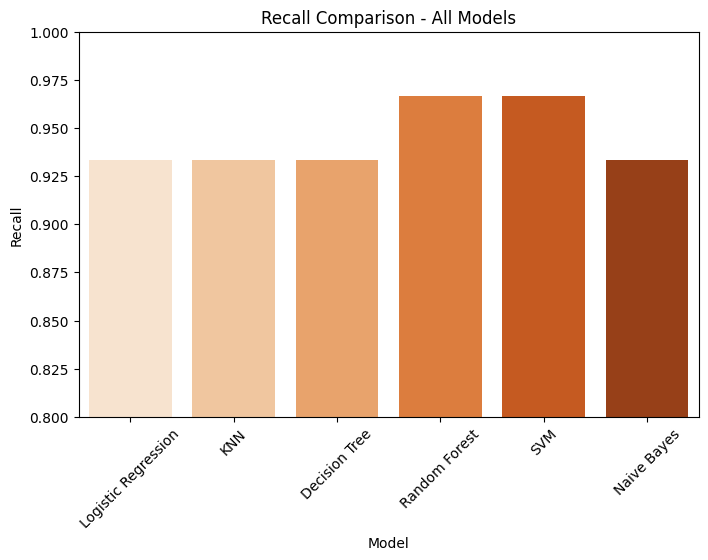

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_results,
    x="Model",
    y="Recall",
    palette="Oranges"
)

plt.title("Recall Comparison - All Models")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.show()

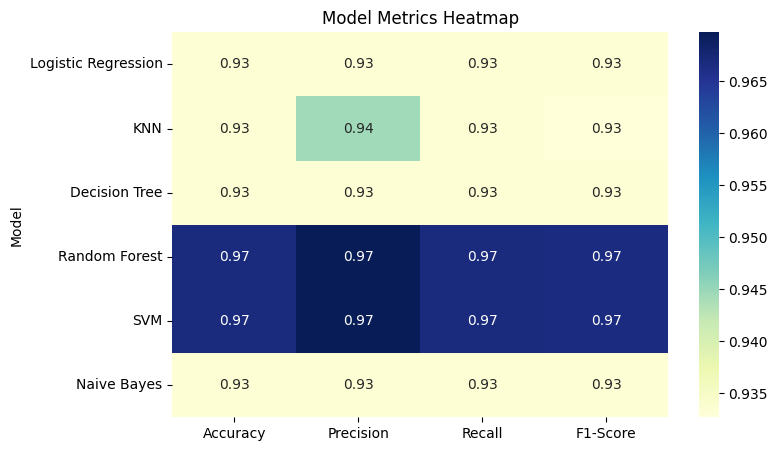

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    df_results.set_index("Model")[["Accuracy","Precision","Recall","F1-Score"]],
    annot=True,
    cmap="YlGnBu"
)

plt.title("Model Metrics Heatmap")
plt.show()

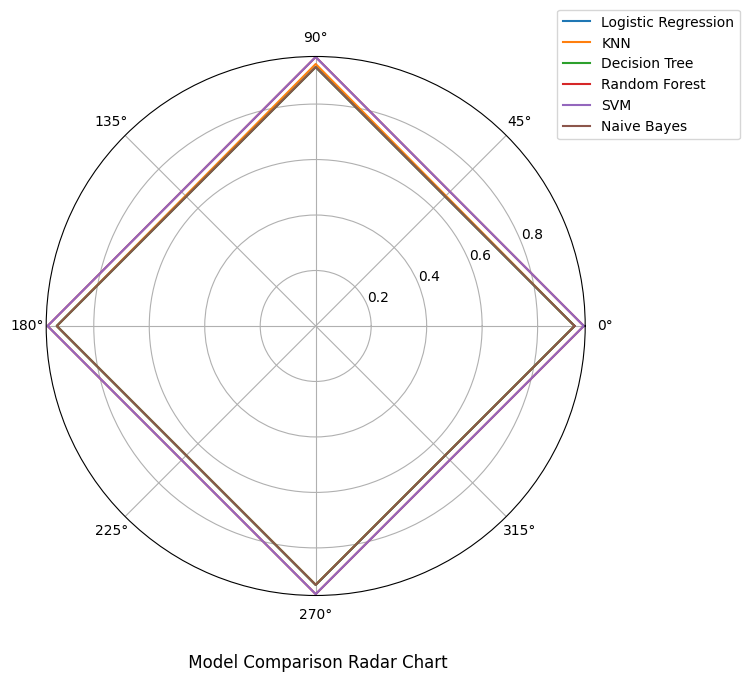

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1-Score"]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))

for i, row in df_results.iterrows():
    values = row[metrics].tolist()
    values += values[:1]

    plt.polar(angles, values, label=row["Model"])


plt.title(" Model Comparison Radar Chart", y=-0.15)

plt.legend(bbox_to_anchor=(1.3, 1.1))
plt.show()

/tmp/ipykernel_579/1916894560.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


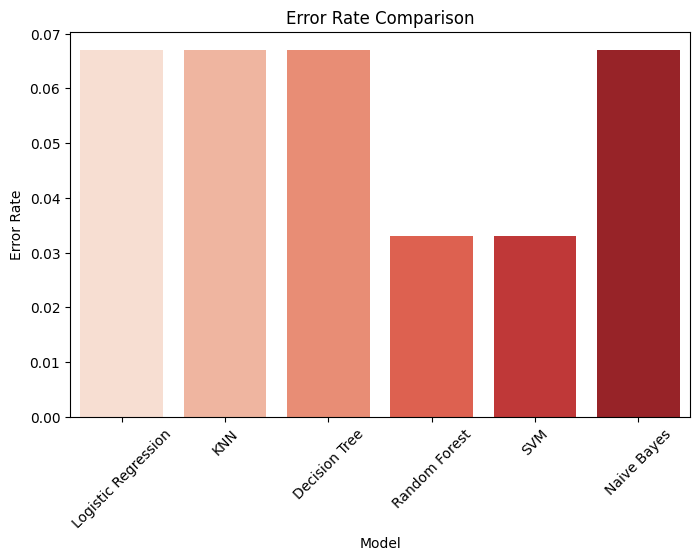

In [ ]:
import numpy as np
df_results["Error Rate"] = 1 - df_results["Accuracy"]
df_results[["Accuracy","Precision","Recall","F1-Score","Error Rate"]] = \
df_results[["Accuracy","Precision","Recall","F1-Score","Error Rate"]].round(3)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_results,
    x="Model",
    y="Error Rate",
    palette="Reds"
)

plt.title("Error Rate Comparison")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_579/1542639415.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


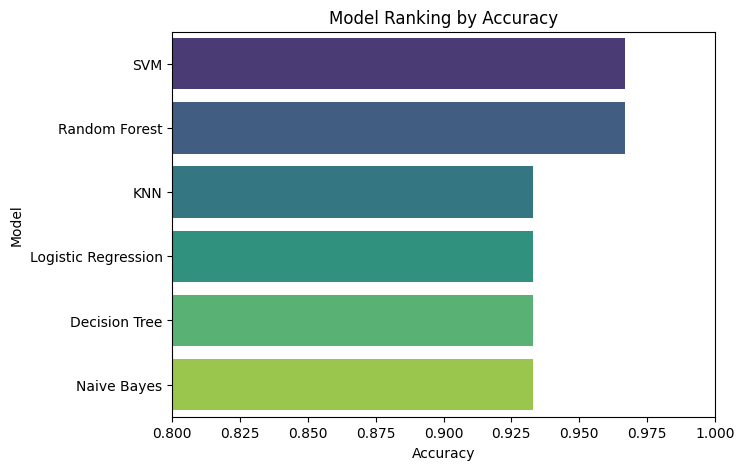

In [ ]:
df_rank = df_results.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    data=df_rank,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Ranking by Accuracy")
plt.xlim(0.8, 1.0)
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

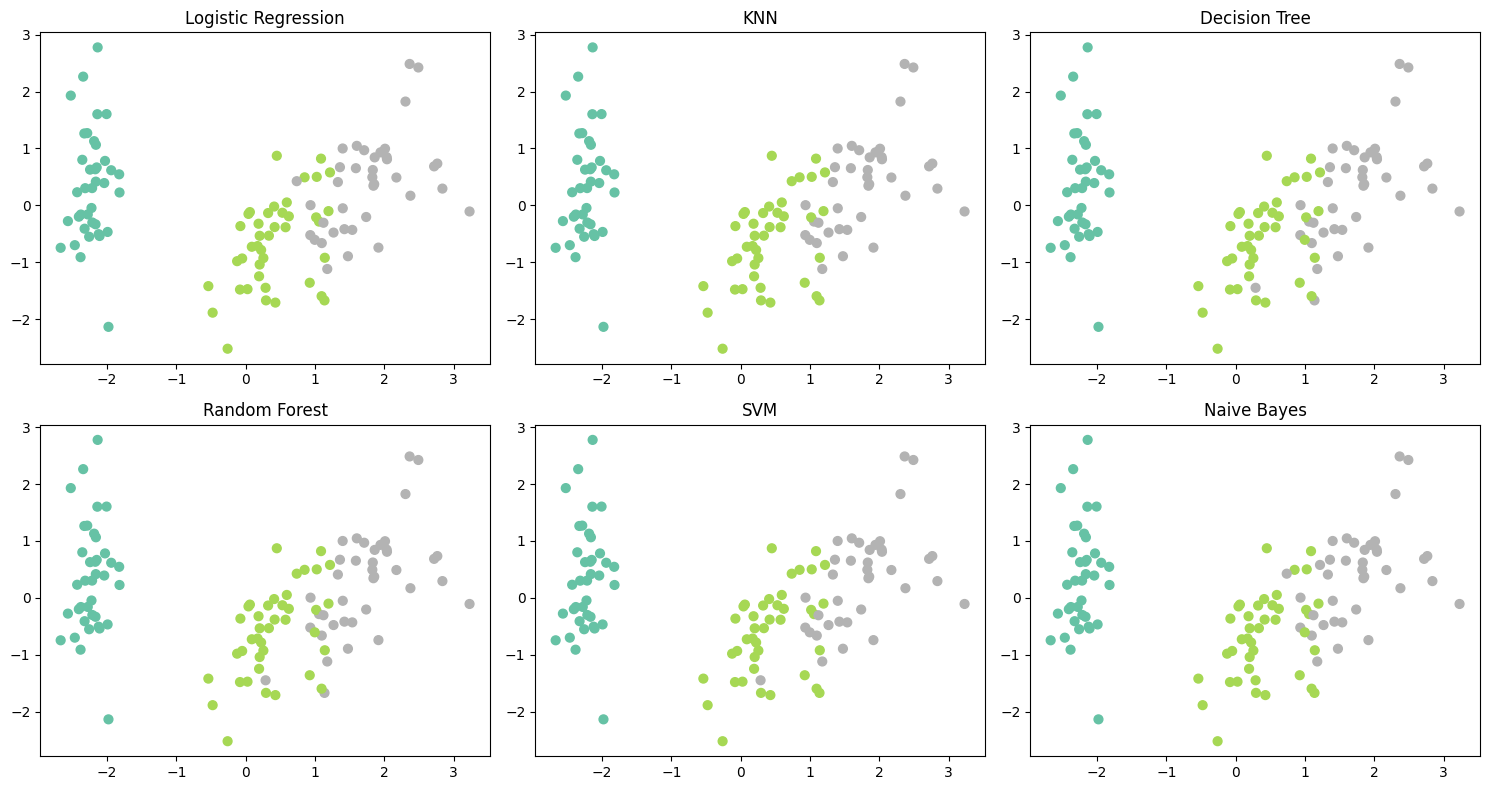

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

models = [
    ("Logistic Regression", log_model),
    ("KNN", knn_model),
    ("Decision Tree", dt_model),
    ("Random Forest", rf_model),
    ("SVM", svm_model),
    ("Naive Bayes", nb_model)
]

for ax, (name, model) in zip(axes.ravel(), models):
    preds = model.predict(X_train_scaled)

    ax.scatter(X_pca[:,0], X_pca[:,1],
               c=preds,
               cmap="Set2",
               s=40)

    ax.set_title(name)

plt.tight_layout()
plt.show()

BEST MODEL

In [ ]:
best_row = df_results.sort_values("Accuracy", ascending=False).iloc[0]

print("Best Model Details:")
print(best_row)

Best Model Details:
Model           SVM
Accuracy      0.967
Precision      0.97
Recall        0.967
F1-Score      0.967
Error Rate    0.033
Name: 4, dtype: object


CLASSIFICATION REPORT

In [ ]:
models = {
    "Logistic Regression": log_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Naive Bayes": nb_model
}
from sklearn.metrics import classification_report

best_model_name = df_results.sort_values("Accuracy", ascending=False).iloc[0]["Model"]

best_model = models[best_model_name]

best_predictions = best_model.predict(X_test_scaled)

report = classification_report(
    y_test,
    best_predictions,
    target_names=encoder.classes_
)

print("Best Model:", best_model_name)
print(report)

Best Model: SVM
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



PREDICTIONS

In [ ]:
new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_flower_scaled = scaler.transform(
    new_flower
)

prediction = best_model.predict(
    new_flower_scaled
)

predicted_species = encoder.inverse_transform(
    prediction
)

print("\nPrediction Result")
print("Predicted Species:",
      predicted_species[0])


Prediction Result
Predicted Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd

# take 15 random samples
idx = np.random.choice(len(X_test_scaled), 15, replace=False)

X_sample = X_test_scaled[idx]
y_actual = y_test.iloc[idx]

# predictions
y_pred = best_model.predict(X_sample)

# convert back to original labels
y_actual_labels = encoder.inverse_transform(y_actual)
y_pred_labels = encoder.inverse_transform(y_pred)

comparison_df = pd.DataFrame({
    "Actual Species": y_actual_labels,
    "Predicted Species": y_pred_labels
})

comparison_df

,Actual Species,Predicted Species
0,Iris-virginica,Iris-virginica
1,Iris-versicolor,Iris-versicolor
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-virginica
4,Iris-setosa,Iris-setosa
5,Iris-virginica,Iris-virginica
6,Iris-setosa,Iris-setosa
7,Iris-setosa,Iris-setosa
8,Iris-setosa,Iris-setosa
9,Iris-virginica,Iris-virginica


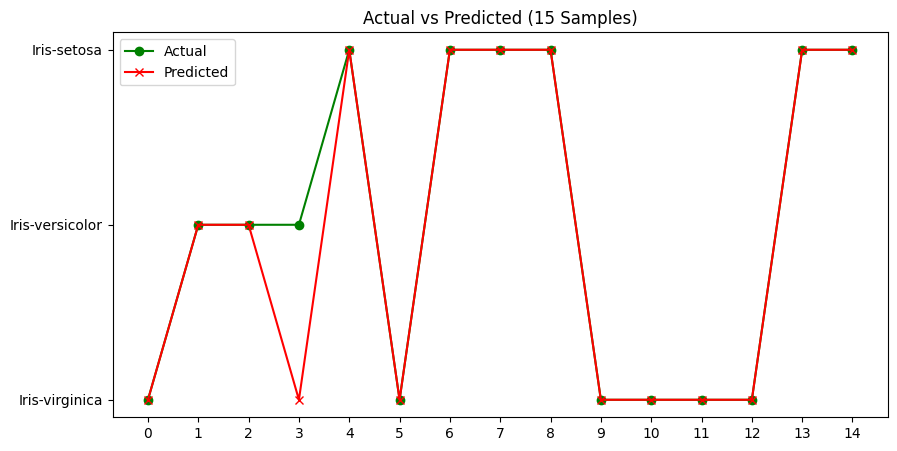

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(comparison_df))

plt.figure(figsize=(10,5))

plt.plot(x, comparison_df["Actual Species"], marker="o", label="Actual", color="green")
plt.plot(x, comparison_df["Predicted Species"], marker="x", label="Predicted", color="red")

plt.xticks(x)
plt.title("Actual vs Predicted (15 Samples)")
plt.legend()
plt.show()

In [ ]:
import numpy as np

print("Iris Species PredictionS")

sepal_length = float(input("Enter Sepal Length: "))
sepal_width  = float(input("Enter Sepal Width: "))
petal_length = float(input("Enter Petal Length: "))
petal_width  = float(input("Enter Petal Width: "))

new_flower = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
new_flower_scaled = scaler.transform(new_flower)
prediction = best_model.predict(new_flower_scaled)
species = encoder.inverse_transform(prediction)

print("Predicted Iris Species:", species[0])

Iris Species PredictionS
Enter Sepal Length: 6.8
Enter Sepal Width: 3.0
Enter Petal Length: 5.5
Enter Petal Width: 2.1
Predicted Iris Species: Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
